<a href="https://colab.research.google.com/github/suvarnaj3/student_score_predictor/blob/main/student_score_predictor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

df = pd.read_csv('student_scores.csv')
print(df.head())

FileNotFoundError: [Errno 2] No such file or directory: 'student_scores.csv'

In [1]:
import os

for root, dirs, files in os.walk('/content/drive/MyDrive'):
    for file in files:
        if file.endswith('.csv'):
            print(os.path.join(root, file))

/content/drive/MyDrive/sepsis_full_processed.csv
/content/drive/MyDrive/sepsis_5000patients_with_id.csv
/content/drive/MyDrive/student_scores.csv
/content/drive/MyDrive/sepsis_project/patient_level_data.csv


In [2]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/student_scores.csv')

print(df.head())

   Hours  Scores
0    2.5      21
1    5.1      47
2    3.2      27
3    8.5      75
4    3.5      30


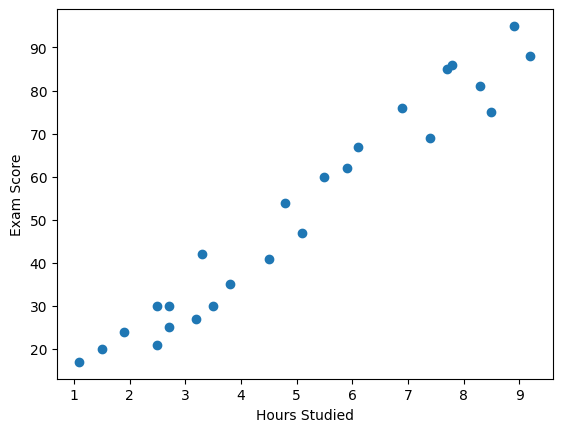

In [6]:
import matplotlib.pyplot as plt

plt.scatter(df['Hours'], df['Scores'])

plt.xlabel("Hours Studied")
plt.ylabel("Exam Score")
plt.show()

In [9]:
from sklearn.model_selection import train_test_split

X = df[['Hours']]
y = df['Scores']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [10]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [11]:
print(model.coef_)
print(model.intercept_)#Score = w × Hours + b

[9.68207815]
2.826892353899737


In [12]:
prediction = model.predict([[6]])

print(prediction) #A student studying 6 hours is expected to score around 60.9.

[60.91936128]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


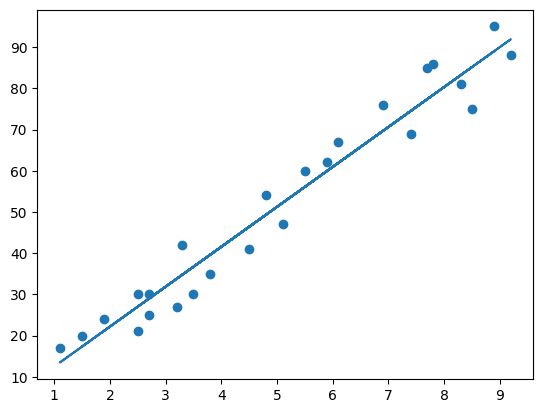

In [13]:
plt.scatter(X, y)

plt.plot(
    X,
    model.predict(X),
)

plt.show()#Blue dots = actual data; Line = learned regression model

In [14]:
from sklearn.metrics import mean_squared_error

predictions = model.predict(X_test)

mse = mean_squared_error(
    y_test,
    predictions
)

print(mse)#MSE Score

18.943211722315272


In [15]:
from sklearn.metrics import r2_score

print(r2_score(y_test, predictions))#R² Score

0.9678055545167994


In [17]:
X = df['Hours'].values
y = df['Scores'].values

In [18]:
w = 0        #We start with a random line:
b = 0

alpha = 0.01      # learning rate
iterations = 1000
#  y_pred = 0*x + 0; which is obviously a bad fit.

In [19]:
y_pred = w * X + b

In [20]:
w = 10
b = 20

x = 4

y_pred = 10*4 + 20

In [21]:
m = len(X)

cost = (1/m) * sum((y_pred - y)**2)

In [22]:
dw = (2/m) * sum((y_pred - y) * X)

db = (2/m) * sum(y_pred - y)

In [23]:
w = w - alpha * dw

b = b - alpha * db

In [24]:
import numpy as np

X = df['Hours'].values
y = df['Scores'].values

w = 0
b = 0

alpha = 0.01
iterations = 1000

m = len(X)

for i in range(iterations):

    # Predictions
    y_pred = w * X + b

    # Cost
    cost = (1/m) * np.sum((y_pred - y)**2)

    # Gradients
    dw = (2/m) * np.sum((y_pred - y) * X)
    db = (2/m) * np.sum(y_pred - y)

    # Update
    w = w - alpha * dw
    b = b - alpha * db

    if i % 100 == 0:
        print(f"Iteration {i}: Cost = {cost}")

Iteration 0: Cost = 3264.04
Iteration 100: Cost = 28.953751869644368
Iteration 200: Cost = 28.915766076967024
Iteration 300: Cost = 28.898096995166824
Iteration 400: Cost = 28.889878226262518
Iteration 500: Cost = 28.886055267997545
Iteration 600: Cost = 28.88427701993319
Iteration 700: Cost = 28.88344986829842
Iteration 800: Cost = 28.883065118925938
Iteration 900: Cost = 28.882886152853214


In [25]:
print("w =", w)
print("b =", b)

w = 9.778905988234964
b = 2.4644522714760995


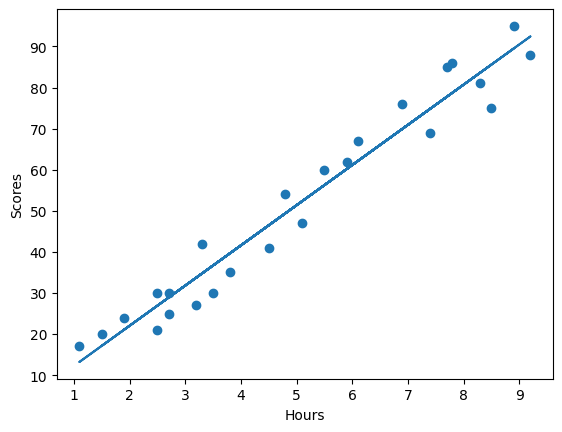

In [26]:
import matplotlib.pyplot as plt

plt.scatter(X, y)

plt.plot(X, w*X + b)

plt.xlabel("Hours")
plt.ylabel("Scores")

plt.show()